# Example notebook on extracting satellite data from NASA

* Pre-requirement: you will need to create an account here: https://urs.earthdata.nasa.gov/users/new

In [ ]:
# Install necessary packages
!pip install earthaccess
!pip install folium

In [1]:
import folium
from folium import plugins

# Xi'an coordinates
xian_lat, xian_lon = 34.3416, 108.9398

# Define the bounding box coordinates for Xi'an
min_lon, min_lat, max_lon, max_lat = 108.7, 34.2, 109.2, 34.5

# Create map centered on Xi'an
m = folium.Map(location=[xian_lat, xian_lon], zoom_start=9)

# Add NASA MODIS layer from GIBS (MODIS Terra true color)
gibs_url = (
    'https://gibs.earthdata.nasa.gov/wmts/epsg3857/best/'
    'MODIS_Terra_CorrectedReflectance_TrueColor/default/'
    '2024-07-01/GoogleMapsCompatible_Level9/{z}/{y}/{x}.jpg'
)

# Add bounding box rectangle
bounding_box = [
    [min_lat, min_lon],  # Southwest corner
    [min_lat, max_lon],  # Southeast corner
    [max_lat, max_lon],  # Northeast corner
    [max_lat, min_lon],  # Northwest corner
    [min_lat, min_lon]   # Close the rectangle
]

folium.PolyLine(
    locations=bounding_box,
    color='red',
    weight=3,
    opacity=0.8,
    popup='MODIS Data Bounding Box',
    tooltip='Study Area Boundary'
).add_to(m)

# Add layer control
folium.LayerControl().add_to(m)

# Display the map
m

In [2]:
import earthaccess
from datetime import datetime

# Authenticate (you may need to set up credentials)
earthaccess.login()

# Define the bounding box coordinates for Xi'an
min_lon, min_lat, max_lon, max_lat = 108.7, 34.2, 109.2, 34.5

# Set time range
start_date = "2024-01-01"
end_date = "2024-08-01"

# Search for MODIS Land Surface Temperature collection
collections = earthaccess.search_datasets(
    short_name="MOD11A1",
    cloud_hosted=True
)

# Search for available granules (files) over Xi'an
granules = earthaccess.search_data(
    short_name="MOD11A1",
    bounding_box=(min_lon, min_lat, max_lon, max_lat),
    temporal=(start_date, end_date),
    cloud_hosted=True,
    count=100,
)

# Debug: Check the structure of granules
print(f"Found {len(granules)} granules")
if len(granules) > 0:
    print("First granule keys:", granules[0].keys() if hasattr(granules[0], 'keys') else dir(granules[0]))
    print("First granule:", granules[0])

c:\Users\kou12\miniconda3\envs\xidian-venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Found 100 granules
First granule keys: dict_keys(['meta', 'umm', 'size'])
First granule: Collection: {'ShortName': 'MOD11A1', 'Version': '061'}
Spatial coverage: {'HorizontalSpatialDomain': {'Geometry': {'GPolygons': [{'Boundary': {'Points': [{'Longitude': 103.926979152633, 'Latitude': 30.0041666666667}, {'Longitude': 115.474935492789, 'Latitude': 30.0041666666667}, {'Longitude': 130.535284930568, 'Latitude': 39.9958333333333}, {'Longitude': 117.481233367399, 'Latitude': 39.9958333333333}, {'Longitude': 103.926979152633, 'Latitude': 30.0041666666667}]}}]}}}
Temporal coverage: {'RangeDateTime': {'BeginningDateTime': '2024-01-01T00:00:00.000Z', 'EndingDateTime': '2024-01-01T23:59:59.000Z'}}
Size(MB): 2.41558
Data: ['https://data.lpdaac.earthdatacloud.nasa.gov/lp-prod-protected/MOD11A1.061/MOD11A1.A2024001.h27v05.061.2024005041326/MOD11A1.A2024001.h27v05.061.2024005041326.hdf']


In [3]:
# Extract available dates
available_dates = sorted(set([g['umm']['TemporalExtent']['RangeDateTime']['BeginningDateTime'] for g in granules]))
available_dates

['2024-01-01T00:00:00.000Z',
 '2024-01-02T00:00:00.000Z',
 '2024-01-03T00:00:00.000Z',
 '2024-01-04T00:00:00.000Z',
 '2024-01-05T00:00:00.000Z',
 '2024-01-06T00:00:00.000Z',
 '2024-01-07T00:00:00.000Z',
 '2024-01-08T00:00:00.000Z',
 '2024-01-09T00:00:00.000Z',
 '2024-01-10T00:00:00.000Z',
 '2024-01-11T00:00:00.000Z',
 '2024-01-12T00:00:00.000Z',
 '2024-01-13T00:00:00.000Z',
 '2024-01-14T00:00:00.000Z',
 '2024-01-15T00:00:00.000Z',
 '2024-01-16T00:00:00.000Z',
 '2024-01-17T00:00:00.000Z',
 '2024-01-18T00:00:00.000Z',
 '2024-01-19T00:00:00.000Z',
 '2024-01-20T00:00:00.000Z',
 '2024-01-21T00:00:00.000Z',
 '2024-01-22T00:00:00.000Z',
 '2024-01-23T00:00:00.000Z',
 '2024-01-24T00:00:00.000Z',
 '2024-01-25T00:00:00.000Z',
 '2024-01-26T00:00:00.000Z',
 '2024-01-27T00:00:00.000Z',
 '2024-01-28T00:00:00.000Z',
 '2024-01-29T00:00:00.000Z',
 '2024-01-30T00:00:00.000Z',
 '2024-01-31T00:00:00.000Z',
 '2024-02-01T00:00:00.000Z',
 '2024-02-02T00:00:00.000Z',
 '2024-02-03T00:00:00.000Z',
 '2024-02-04T0

In [4]:
# Download the granules to local storage
downloaded_files = earthaccess.download(
    granules[:5],  # Download first 5 granules as example
    local_path="./modis_data/",  # Local directory to save files
    provider="POCLOUD"  # Cloud provider (use POCLOUD for cloud-hosted data)
)

print(f"Downloaded {len(downloaded_files)} files:")
for file in downloaded_files:
    print(f"  - {file}")

QUEUEING TASKS | : 100%|██████████| 5/5 [00:00<00:00, 790.07it/s]
PROCESSING TASKS | : 100%|██████████| 5/5 [00:05<00:00,  1.01s/it]
COLLECTING RESULTS | : 100%|██████████| 5/5 [00:00<?, ?it/s]

Downloaded 5 files:
  - modis_data\MOD11A1.A2024001.h27v05.061.2024005041326.hdf
  - modis_data\MOD11A1.A2024001.h26v05.061.2024005041227.hdf
  - modis_data\MOD11A1.A2024002.h26v05.061.2024005052250.hdf
  - modis_data\MOD11A1.A2024002.h27v05.061.2024005053710.hdf
  - modis_data\MOD11A1.A2024003.h26v05.061.2024005155203.hdf


In [5]:
import numpy as np
import matplotlib.pyplot as plt
from pyhdf.SD import SD, SDC
import os

def extract_lst_from_hdf(hdf_file):
    """
    Extract Land Surface Temperature from MODIS HDF file
    """
    try:
        # Open HDF file
        hdf = SD(hdf_file, SDC.READ)
        
        # Get LST datasets (Day and Night)
        lst_day = hdf.select('LST_Day_1km')
        lst_night = hdf.select('LST_Night_1km')
        
        # Read the data
        lst_day_data = lst_day.get()
        lst_night_data = lst_night.get()
        
        # Get scale and offset attributes
        day_attrs = lst_day.attributes()
        night_attrs = lst_night.attributes()
        
        # Apply scaling: Temperature = DN * scale_factor + add_offset
        day_scale = day_attrs.get('scale_factor', 0.02)
        day_offset = day_attrs.get('add_offset', 0.0)
        night_scale = night_attrs.get('scale_factor', 0.02)  
        night_offset = night_attrs.get('add_offset', 0.0)
        
        # Convert to actual temperature (Kelvin)
        lst_day_temp = lst_day_data * day_scale + day_offset
        lst_night_temp = lst_night_data * night_scale + night_offset
        
        # Convert to Celsius
        lst_day_celsius = lst_day_temp - 273.15
        lst_night_celsius = lst_night_temp - 273.15
        
        # Handle fill values (typically 0 or very high values)
        lst_day_celsius[lst_day_data == 0] = np.nan
        lst_night_celsius[lst_night_data == 0] = np.nan
        
        hdf.end()
        
        return lst_day_celsius, lst_night_celsius
        
    except Exception as e:
        print(f"Error processing {hdf_file}: {e}")
        return None, None

# Process downloaded files
for hdf_file in downloaded_files:
    if hdf_file.endswith('.hdf'):
        print(f"Processing: {hdf_file}")
        day_temp, night_temp = extract_lst_from_hdf(hdf_file)
        
        if day_temp is not None:
            print(f"Day temperature range: {np.nanmin(day_temp):.1f}°C to {np.nanmax(day_temp):.1f}°C")
            print(f"Night temperature range: {np.nanmin(night_temp):.1f}°C to {np.nanmax(night_temp):.1f}°C")

Processing: modis_data\MOD11A1.A2024001.h27v05.061.2024005041326.hdf
Day temperature range: -13.4°C to 11.1°C
Night temperature range: -22.4°C to 5.8°C
Processing: modis_data\MOD11A1.A2024001.h26v05.061.2024005041227.hdf
Day temperature range: -27.8°C to 19.9°C
Night temperature range: -44.8°C to 8.2°C
Processing: modis_data\MOD11A1.A2024002.h26v05.061.2024005052250.hdf
Day temperature range: -29.7°C to 16.8°C
Night temperature range: -40.9°C to 8.2°C
Processing: modis_data\MOD11A1.A2024002.h27v05.061.2024005053710.hdf
Day temperature range: -20.7°C to 15.0°C
Night temperature range: -23.9°C to 12.2°C
Processing: modis_data\MOD11A1.A2024003.h26v05.061.2024005155203.hdf
Day temperature range: -25.1°C to 18.2°C
Night temperature range: -39.6°C to 9.4°C


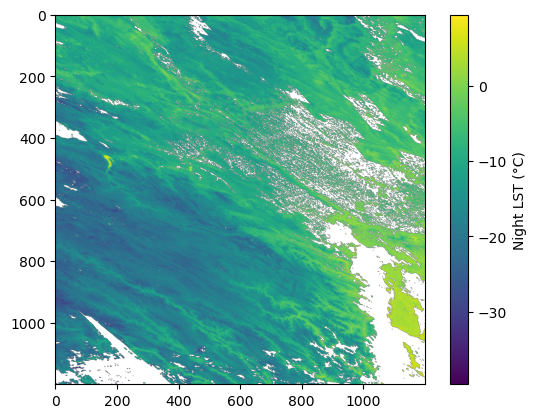

In [6]:
plt.imshow(night_temp)
plt.colorbar(label='Night LST (°C)')